# Trabajo final Deep Learning
Pablo Andrés Peláez Cardona

pabloa.pelaez@udea.edu.co

## Contextualización del problema
El analisis de imagenes satelitales es uno de los campos de aplicación del machine learning actual. A través del cuál se extrae información util del planeta a gran escala y de forma automatica.

Algunas aplicaciones del machine learning en analisis de imagenes satelitales son:

### Monitoreo ambiental
- Vigilar bosques (detectar zonas de deforestación)
- Vigilar y mediar areas de glaciares
- Contaminación de rios y oceanos
- Incendios forestales o residenciales a gran escala.

### Crecimiento y planeación urbana
- Analisis de uso de suelo en ciudades.
- Ejericios de expansión urbana y/o construcción en ciudades.
- Planificación de espacios a futuro (POT)

### Defensa
- Detección/Acumulación de fuerzas militares en determinada zona
- vigilancia fronteriza
### Agricultura
- Vigilancia de cultivos
- Detección de plagas
- Conteo de arboles
- Analisis de fuentes hidricas

Si bien es posible utilizar modelos de machine learning "clásicos para el analisis de imagenes satelitales", el deep learning permite:
- Manejar mayores cantidades de datos
- Identificar patrones automaticamente
- Flexibilidad frente al ruido/variabilidad
- Analisis temporal de imagenes

Para este caso de estudio en particular vamos a utilizar un modelo de deep learning para clasificar imagenes satelitales. Para esto, utilizaremos un transfer learning de modelos robustos previamente entrenados, a los cuáles haremos un fine tunning y agregaremos algunas capas propias.
El proceso coincide en:

1. Tomar el modelo previamente entrenado (Transfer learning)
2. Congelar las primeras capas (Fine tunning)
3. Agregar capas propias
4. Entrenamiento y evaluación con base de datos de imagenes satelitales.
5. Evaluación de imagenes propias extraidas de Google maps.
6. Comparación entre diferentes modelos base.

## ¿Qué Base de imagenes satelitales vamos a usar?

Lo primero, es aclarar que los modelos previamente entrenados, utilizan imagenes generales, no satelitales. Pero al usar este tipo de modelos previamente entrenados con imagenes (aunque no sean del objetivo del proyecto) auumenta la precisión y los tiempos de entrenamiento del nuevo modelo.

La base de imagenes satelitales que vamos a utilizar es **EuroSat Dataset**. Una colección de imagenes satelitales tomadas por el satelite Sentinel-2 para la European Space Agency en su *Copernicus Programme*.
La base contiene 27.000 imagenes satelitales de 64x64 pixeles, etiquetadas en las siguientes categorias:
- AnnualCrop
- Forest
- HerbaceousVegatation
- Highway
- Industrial
- Pasture
- PermanentCrop
- Residential
- River
- SeaLake




# Importación de librerias

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

from PIL import Image

import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import gdown
import zipfile
import os

## Revisamos si la GPU está disponible para utilizar

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Definimos las transformaciónes
Antes de cargar las imagenes, definimos los parametros de estandarización.
- Imagenes de 64x64
- Random Horizontal Flip: Esto voltea aleatoriamente algunas imagenes. Esto potencia el entrenamiento y reduce overfitting.
- To tensor: Convierte las imagenes en tensores de entrada para el modelo (En forma de array)

In [2]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

# Cargamos El dataset
Y aplicamos las transformaciones previamente definidas

In [3]:

file_id = "1St_AwJIKd2ZlrAs_IqeDTX_-zrT8nZsJ"
file_id2 = "1fplPxQKSGAtS_jyVUHw81EgVd1aVDPjl"

# descargar zip
gdown.download(f"https://drive.google.com/uc?id={file_id}", "EuroSAT.zip", quiet=False)
gdown.download(f"https://drive.google.com/uc?id={file_id2}", "imagenes.zip", quiet=False)

#  descomprimir
with zipfile.ZipFile("EuroSAT.zip", 'r') as zip_ref:
    zip_ref.extractall("EuroSAT")

with zipfile.ZipFile("imagenes.zip", 'r') as zip_ref:
    zip_ref.extractall("imagenes")

def encontrar_data_dir(base_path):
    current_path = base_path
    while True:
        contenido = os.listdir(current_path)

        # Si solo hay un elemento y es un directorio, desciende en él
        if len(contenido) == 1 and os.path.isdir(os.path.join(current_path, contenido[0])):
            current_path = os.path.join(current_path, contenido[0])
        # De lo contrario, esta 'current_path' debe ser la que contiene las carpetas de clases o archivos.
        else:
            return current_path

data_dir = encontrar_data_dir("EuroSAT")
img_dir = encontrar_data_dir("imagenes")

print("Ruta final del dataset:", data_dir)
print("Contenido final del directorio:", os.listdir(data_dir))

# Inicializar el full_dataset con la ruta correcta
full_dataset = datasets.ImageFolder(data_dir, transform=transform)
print("Clases detectadas por ImageFolder:", full_dataset.classes)

Downloading...
From (original): https://drive.google.com/uc?id=1St_AwJIKd2ZlrAs_IqeDTX_-zrT8nZsJ
From (redirected): https://drive.google.com/uc?id=1St_AwJIKd2ZlrAs_IqeDTX_-zrT8nZsJ&confirm=t&uuid=afa85fbd-babe-485e-92e3-dea3326512f4
To: /content/EuroSAT.zip
100%|██████████| 95.2M/95.2M [00:01<00:00, 67.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1fplPxQKSGAtS_jyVUHw81EgVd1aVDPjl
To: /content/imagenes.zip
100%|██████████| 738k/738k [00:00<00:00, 6.50MB/s]


Ruta final del dataset: EuroSAT/EuroSAT
Contenido final del directorio: ['PermanentCrop', 'River', 'Highway', 'label_map.json', 'HerbaceousVegetation', 'Pasture', 'test.csv', 'Residential', 'AnnualCrop', 'Industrial', 'SeaLake', 'Forest', 'train.csv', 'validation.csv']
Clases detectadas por ImageFolder: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


# Reducción de muestra
Reducimos la muestra de 27.000 imagenes aproximadamente a 20.000 para simplificar el entrenamiento. Inicialmente se había hecho una reducción de muestra a 2.000 muestras, pero debido a la optimización con GPU el entrenamiento duró menos de lo esperado, por \lo que se decidió aumentar el tamaño de la muestra.

In [4]:
subset_size = 20000

dataset, _ = torch.utils.data.random_split(
    full_dataset,
    [subset_size, len(full_dataset) - subset_size]
)

Definición de las bases de entrenamiento y validación. Junto con una semilla para tener replicabilidad al repetir las pruebas.

In [5]:
generator = torch.Generator().manual_seed(42)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size],
    generator=generator
)

Definición del numero de imágenes para el batch y aplicación del parámetro shuffle, para evitar que el modelo aprenda a reconocer las imagenes en orden.

In [6]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

# Transfer Learning y fine tunning
Inicialmente llamamos a la preentrenada red **ResNET18** (transfer learning). A la cuál le congelamos las primeras capas y descongelamos las ultimas para realizar un fine tunning.

In [7]:
model = models.resnet18(weights="IMAGENET1K_V1")

# congelar todo
for param in model.parameters():
    param.requires_grad = False

# descongelar últimas capas
for param in model.layer4.parameters():
    param.requires_grad = True

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 175MB/s]


Definición del número de clases y construcción de capas adicionales:

- Agregamos una capa lineal, con el mismo numero de entradas que la capa anterior de la ResNET.
- Una capa ReLu, para analizar relaciones no lineales. Además de que es muy utilizada en este tipo de problemas.
- Una BatchNorm1d, para normalizar y añadir convergencia al modelo
- y finalmente otra lineal, reemplazando las 1000 clases de imagenet.

In [8]:
num_classes = len(full_dataset.classes)

model.fc = nn.Sequential(
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.BatchNorm1d(256),
    nn.Linear(256, num_classes)
)

Movemos el analisis a la GPU

In [12]:
model = model.to(device)

# Definición de función de perdida y optimizador

Utilizamos crossentropy debido a que tenemos un problema de clasifiación multiclase, y esta función de perdida combina tanto un softmax como un log loss.
Para el caso de la función de optimizador adam es basado es un optimizador basado en gradiente y es bastante utlizado en este tipo de aplicaciones.

In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

Conteo del número de parametros

In [14]:
data = []

total_params = 0
trainable_params = 0

for name, param in model.named_parameters():
    num_params = param.numel()
    total_params += num_params

    if param.requires_grad:
        trainable_params += num_params

    data.append([
        name,
        num_params,
        param.requires_grad
    ])

df = pd.DataFrame(data, columns=["Layer", "Params", "Trainable"])

print(df)

print("\nResumen:")
print(f"Total parámetros: {total_params:,}")
print(f"Entrenables: {trainable_params:,}")
print(f"No entrenables: {total_params - trainable_params:,}")

                    Layer  Params  Trainable
0            conv1.weight    9408      False
1              bn1.weight      64      False
2                bn1.bias      64      False
3   layer1.0.conv1.weight   36864      False
4     layer1.0.bn1.weight      64      False
..                    ...     ...        ...
61              fc.0.bias     256       True
62            fc.2.weight     256       True
63              fc.2.bias     256       True
64            fc.3.weight    2560       True
65              fc.3.bias      10       True

[66 rows x 3 columns]

Resumen:
Total parámetros: 11,310,922
Entrenables: 8,528,138
No entrenables: 2,782,784


# Entrenamiento del modelo
Inicialmente se usaron 5 epocas, pero al ver que corría relativamente rápido se aumentó a 10, observando que ya a partir de 10 el aumento en accuracy no era mucho.

In [15]:
epochs = 10

train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)


    model.eval()
    val_loss = 0

    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            loss = criterion(outputs, y)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

Epoch 1, Train Loss: 0.5262, Val Loss: 0.2290
Epoch 2, Train Loss: 0.3241, Val Loss: 0.2098
Epoch 3, Train Loss: 0.2824, Val Loss: 0.1901
Epoch 4, Train Loss: 0.2337, Val Loss: 0.2347
Epoch 5, Train Loss: 0.2044, Val Loss: 0.1950
Epoch 6, Train Loss: 0.1800, Val Loss: 0.1833
Epoch 7, Train Loss: 0.1562, Val Loss: 0.1888
Epoch 8, Train Loss: 0.1508, Val Loss: 0.2041
Epoch 9, Train Loss: 0.1328, Val Loss: 0.1785
Epoch 10, Train Loss: 0.1217, Val Loss: 0.1681


# Evaluación del modelo

Observamos un accuracy relativamente alto (93.3%) pero cabe aclarar que en otras pruebas antes de utilizar la semilla al momento de partición de las muestras de entrenamiento y validación, en algunos casos se logró alcanzar un 95%. Lo cuál es normal al ser un proceso estocástico que entrega variabilidad.

In [16]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for X, y in val_loader:
        X, y = X.to(device), y.to(device)

        outputs = model(X)
        _, predicted = torch.max(outputs, 1)

        total += y.size(0)
        correct += (predicted == y).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 94.38%


En la gráfica de convergencia, podemos observar como tanto el train loss como el van loss siguen una tendencia descendente. No se observa un overfitting critico (que baje el train loss pero el val loss no).

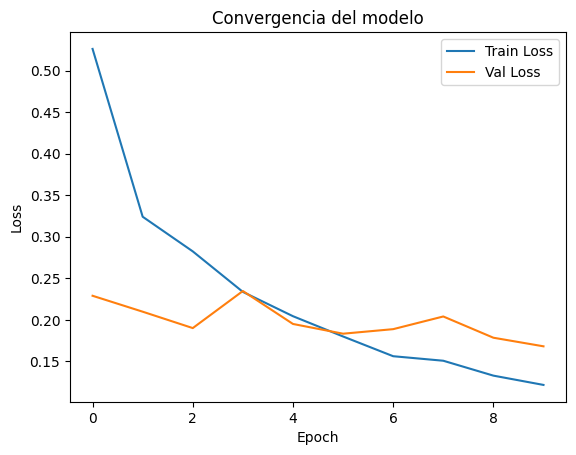

In [17]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Convergencia del modelo")
plt.legend()

plt.show()

# Matriz de confusión

La matriz de confusión nos permite entender cómo está entendiendo las diferentes clases y su debido performance. A partir de la matriz podemos concluir:

- Existen clases que el modelo no tiene problema en clasificar, como los **Sea lake** (>99%). Posiblemente porque no hayan otras clases relativamente similares a grandes porciones de agua.

- Existen clases con bastante más confusión que las demás (~90%) como **Rivers**, **Permanentcrop** y **highway**. Analizando más a detalle encontramos que entre **Rivers** y **Highway** existe una confusión de un *6%*. Posiblemente a los patrones geométricos similares entre ríos y autopistas. Por el lado de **Permanentcrop** que hace referencia a cultivos estacionarios que demoran varios años existe una confusión alta con **Annualcrop** que hace referencia a cultivos de menor tiempo. Esta confusión es bien entendible. Pero habría que analizar más a detalle por que aun así **Annualcrop** tiene un recall de 92% mientras que **permanentcrop** de 90%.

- Existe otra confusión grande entre **Industrial** y **Residential**. Más adelante evaluaremos una imagen de google maps de una urbanización residencial, y antes de estandarizar las bases con la semilla la clasificación para esa imagen cambiaba de industrial y residencial según el modelo. Esto es entendible debido a que zonas residenciales como casas y zonas industriales como fabricas desde el aire pueden tener ciertas caractericas similares, como techos y vías aledañas.

- También existen otras confusiones altas entre **Pasture** y **Herbaceousvegetation** al igual que **Herbaceousvegetation** y **Permanentcrop**. Esto debido a las caractericas vegetales similares desde al aire entre el césped y cobertura vegetal herbarea, al igual que la cobertura vegetal herbarea y los cultivos permanentes.

<Figure size 1200x800 with 0 Axes>

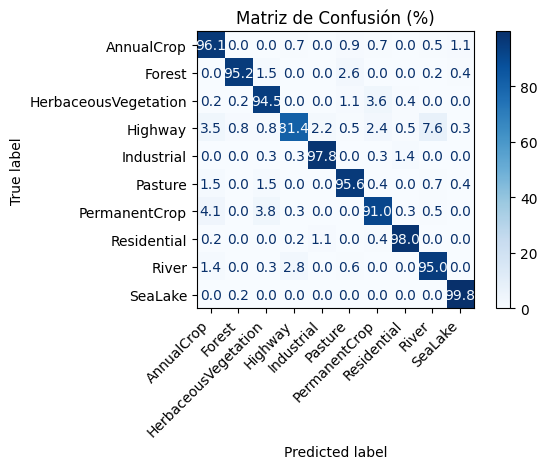

In [ ]:
y_true_resnet = []
y_pred_resnet = []

model.eval()

with torch.no_grad():
    for X, y in val_loader:
        X = X.to(device)

        outputs = model(X)
        _, preds = torch.max(outputs, 1)

        y_true_resnet.extend(y.numpy())
        y_pred_resnet.extend(preds.cpu().numpy())

# matriz de confusión normalizada
cm = confusion_matrix(y_true_resnet, y_pred_resnet, normalize='true')

# convertir a porcentaje
cm_percent = cm * 100

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_percent,
    display_labels=full_dataset.classes
)

plt.figure(figsize=(12, 8))

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    values_format=".1f"
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.title("Matriz de Confusión (%)")
plt.tight_layout()
plt.show()



# Aplicación de diferentes métricas

Tal y como advertimos con la matriz de confusión existen clases que tienen más dificultad para clasificarse como highway y permanent crop aunque su recall y f1 score no sean particularmente bajos con respecto a las otras clases

In [ ]:
print(classification_report(
    y_true_resnet,
    y_pred_resnet,
    target_names=full_dataset.dataset.classes if hasattr(full_dataset, 'dataset') else full_dataset.classes
))

                      precision    recall  f1-score   support

          AnnualCrop       0.91      0.96      0.94       440
              Forest       0.99      0.95      0.97       457
HerbaceousVegetation       0.94      0.95      0.94       474
             Highway       0.95      0.81      0.88       370
          Industrial       0.96      0.98      0.97       363
             Pasture       0.91      0.96      0.93       274
       PermanentCrop       0.91      0.91      0.91       390
         Residential       0.98      0.98      0.98       453
               River       0.91      0.95      0.93       362
             SeaLake       0.98      1.00      0.99       417

            accuracy                           0.95      4000
           macro avg       0.94      0.94      0.94      4000
        weighted avg       0.95      0.95      0.95      4000



# Evaluación del modelo con imagenes de Google maps
Para la evaluación utilizaremos una serie de imagenes sacadas directamente de google maps.

**Zona residencial en Envigado, Antioquia.**

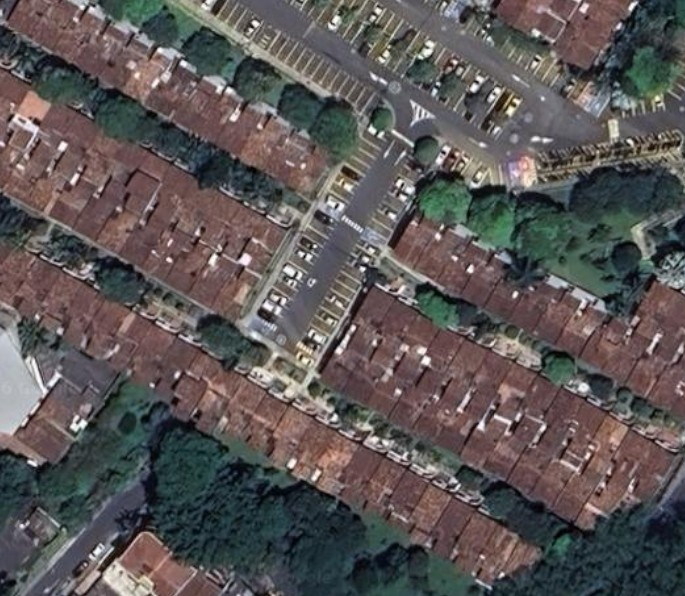

**Rio Putumayo cerca al amazonas.**

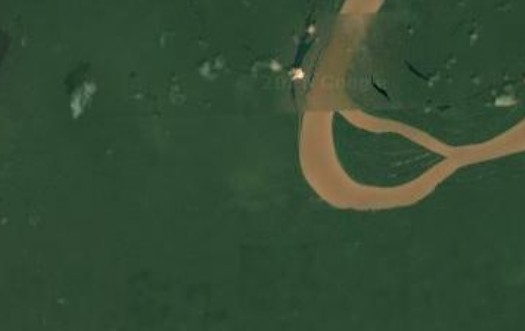

**Reserva de agua de Guatapé**

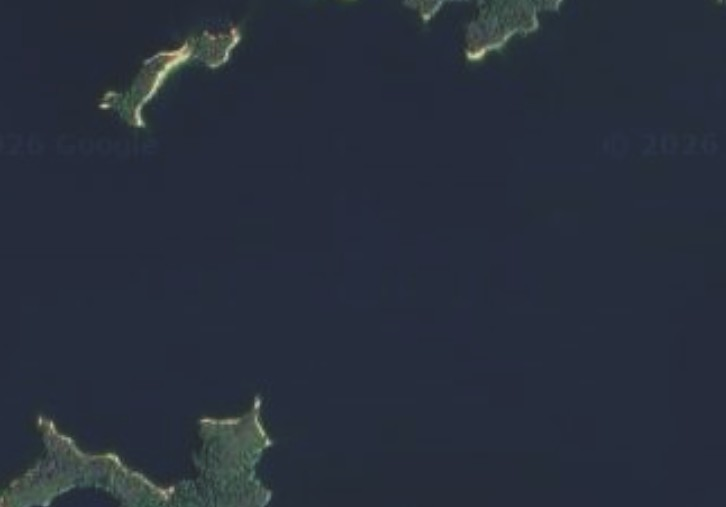

**Autopista norte**

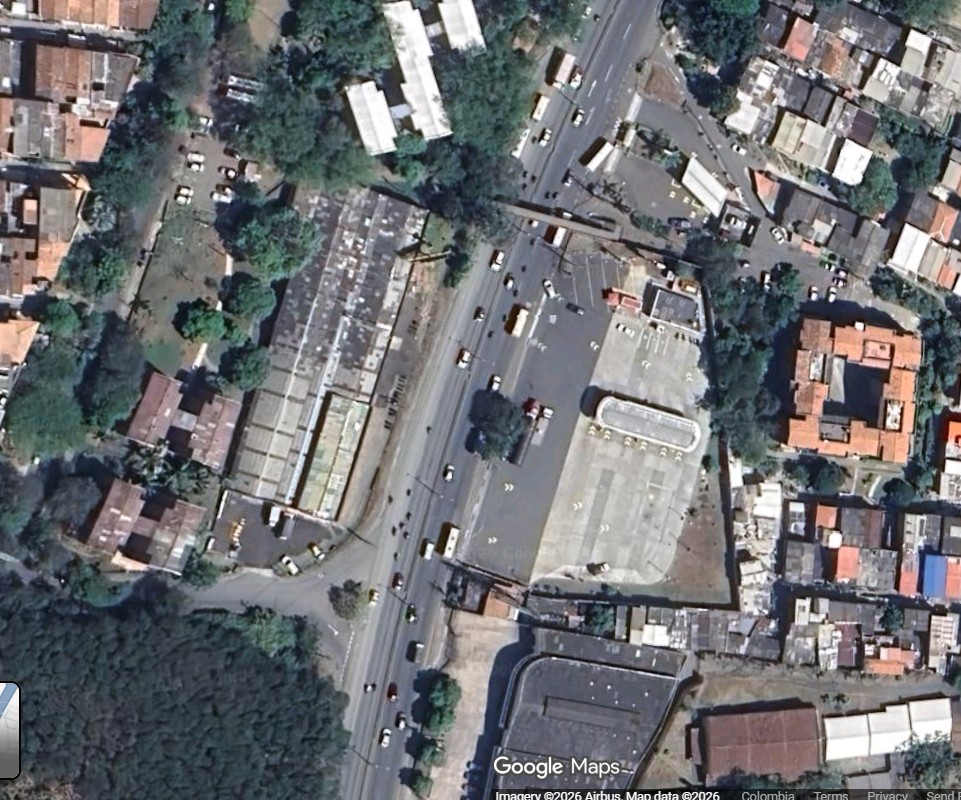

**Ingenio de azucar en el valle del cauca**

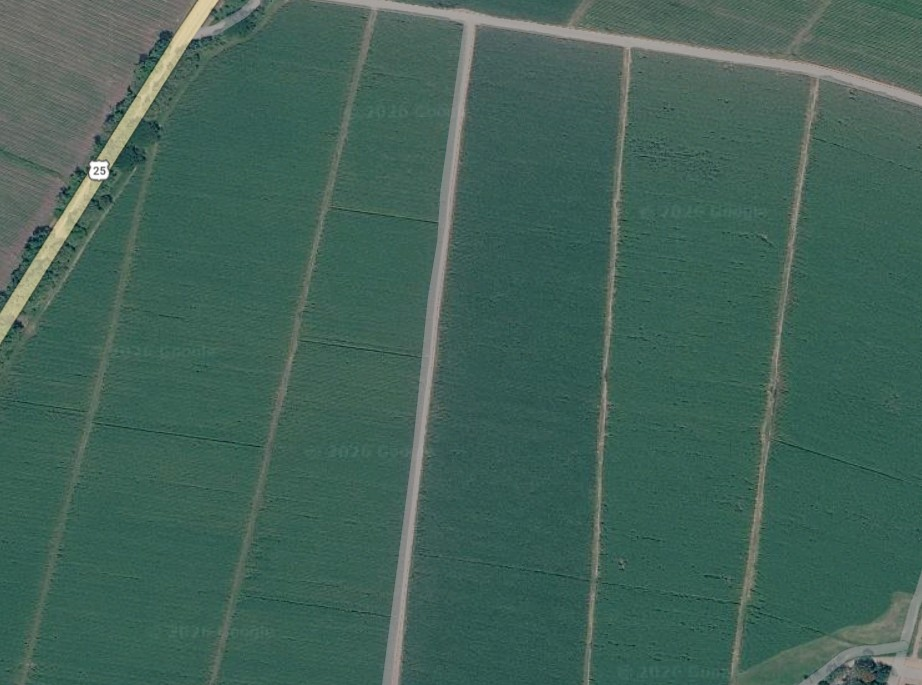

**Plaza minorista**

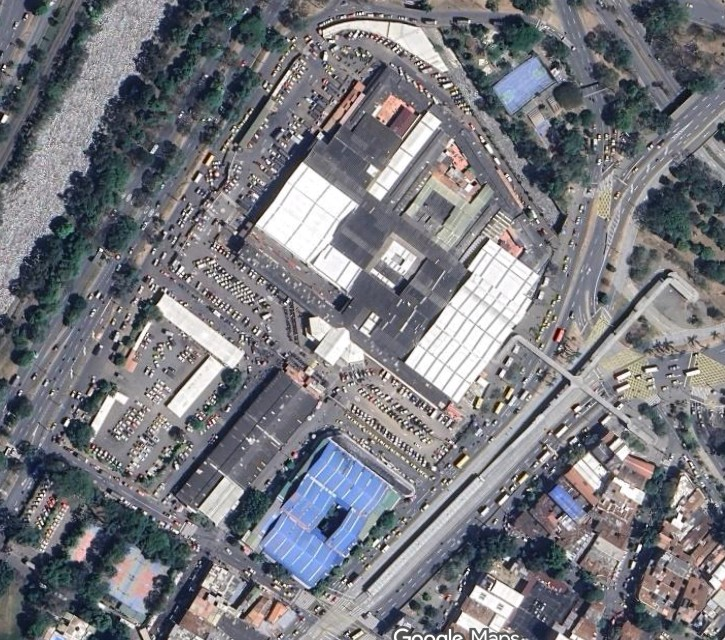

Zona residencial


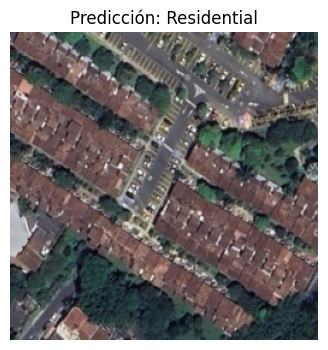

imagenes/unidad.jpg → Residential
Rio Putumayo


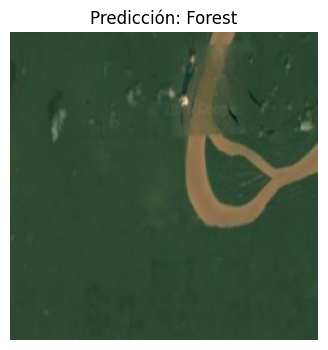

imagenes/rio putumayo.jpg → Forest
Guatapé


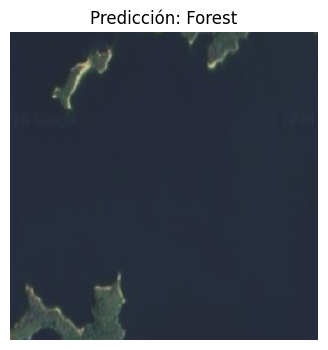

imagenes/guatape.jpg → Forest
Autopista norte


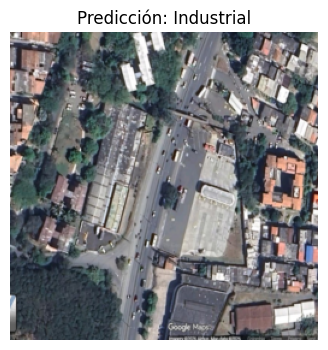

imagenes/autopista norte.jpg → Industrial
Azucar manuelita


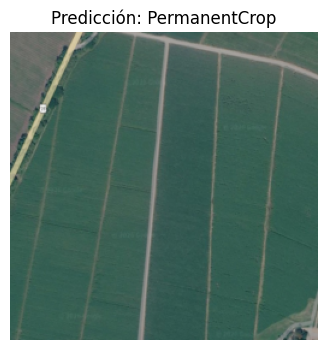

imagenes/azucar manuelita.jpg → PermanentCrop
Plaza minorista


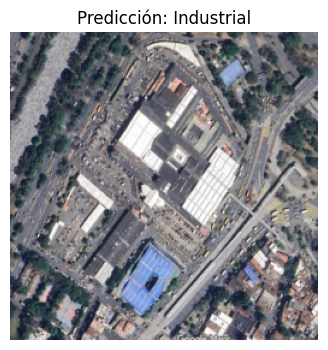

imagenes/plaza minorista.jpg → Industrial


In [ ]:
def predecir_imagen(path):
    img = Image.open(path).convert("RGB")
    img_display = transforms.Resize((256, 256))(img) # Resize for display
    img = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(img)
        _, pred = torch.max(outputs, 1)

    clase = full_dataset.classes[pred.item()]

    plt.figure(figsize=(4, 4))
    plt.imshow(img_display)
    plt.title(f"Predicción: {clase}")
    plt.axis('off')
    plt.show()

    print(path, "→", clase)

print("Zona residencial")
predecir_imagen(os.path.join(img_dir, "unidad.jpg"))
print("Rio Putumayo")
predecir_imagen(os.path.join(img_dir, "rio putumayo.jpg"))
print("Guatapé")
predecir_imagen(os.path.join(img_dir, "guatape.jpg"))
print("Autopista norte")
predecir_imagen(os.path.join(img_dir, "autopista norte.jpg"))
print("Azucar manuelita")
predecir_imagen(os.path.join(img_dir, "azucar manuelita.jpg"))
print("Plaza minorista")
predecir_imagen(os.path.join(img_dir, "plaza minorista.jpg"))

- Como mencionamos antes, el modelo presenta la confusión para identificar la zona residencial cuando se entrena con menos de 10.000 imagenes, pero con 20.000 o más la comienza a clasificar bien.

- Para el caso del rio putumayo lo clasifica como bosque, esto no está del todo mal ya que la foto es del rio en medio de la selva amazonica.

- Guatapé lo clasifica de forma correcta debido a su cuerpo de agua.

- Autopista norte lo clasifica como zona industrial. Esto no está del todo mal. Ya que si observamos la imagen está rodeada de aparatos industriales. Y habría que mirar más a fondo con qué tipo de autopistas está entrenando el modelo (autopistas de muchos carriles y más predominantes en una imagen).

- El ingenio de azucar manuelita lo clasifica de manera correcta. Se podría mirar si un cultivo de azucar entra en la categoria de annualcrop o permanentcrop. Debido a que generalmente una cosecha demora entre 1 a 1.5 años en colombia.

- La plaza minorista lo clasifica de manera correcta.

# Ahora con un transfer learning de un modelo diferente
Ya que vimos los resultados de **ResNET18** vamos a comparar con el modelo **VGG16**. Las diferencias entre los 2 modelos nos permitirán observar diferenciar en su desempeño y tiempo de computación. Mientras que la VGG es una red secuencial clasica (con muchos más parámetros) la ResNet permite realizar saltos entre capas, lo que a su vez aumenta sus cálculos internos.

## Llamamos al modelo preentrenado VGG16 para el transfer learning

In [27]:
model = models.vgg16(weights="IMAGENET1K_V1")

Congelamos las primeras capas y dejamos las ultimas para el fine tunning

In [28]:
for param in model.parameters():
    param.requires_grad = False

for param in model.features[24:].parameters():
    param.requires_grad = True

Definimos el numero de clases y movemos el modelo a la gpu

In [29]:
num_classes = len(full_dataset.classes)

model.classifier = nn.Sequential(
    nn.Linear(25088, 512),
    nn.ReLU(),
    nn.Dropout(0.5),

    nn.Linear(512, num_classes)
)

model = model.to(device)

# Definimos la función de perdida y el optimizador

In [30]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

Calculamos el numero de parametros. Para este caso, se buscó que el número de parámetros entrenables fuera relativamente comparable con la red que usó Resnet (que tiene 8 millones aprox). La BGG tendrá 7 millones de parámetros aprox. para entrenar

In [31]:
data = []

total_params = 0
trainable_params = 0

for name, param in model.named_parameters():
    num_params = param.numel()
    total_params += num_params

    if param.requires_grad:
        trainable_params += num_params

    data.append([
        name,
        num_params,
        param.requires_grad
    ])

df = pd.DataFrame(data, columns=["Layer", "Params", "Trainable"])

print(df)

print("\nResumen:")
print(f"Total parámetros: {total_params:,}")
print(f"Entrenables: {trainable_params:,}")
print(f"No entrenables: {total_params - trainable_params:,}")

                  Layer    Params  Trainable
0     features.0.weight      1728      False
1       features.0.bias        64      False
2     features.2.weight     36864      False
3       features.2.bias        64      False
4     features.5.weight     73728      False
5       features.5.bias       128      False
6     features.7.weight    147456      False
7       features.7.bias       128      False
8    features.10.weight    294912      False
9      features.10.bias       256      False
10   features.12.weight    589824      False
11     features.12.bias       256      False
12   features.14.weight    589824      False
13     features.14.bias       256      False
14   features.17.weight   1179648      False
15     features.17.bias       512      False
16   features.19.weight   2359296      False
17     features.19.bias       512      False
18   features.21.weight   2359296      False
19     features.21.bias       512      False
20   features.24.weight   2359296       True
21     fea

# Realizamos el entrenamiento

Con igual número de épocas y catnidad de batch, el entrenamiento demora más utilizando el preentrenamiento de VGG que el de ResNET. Esto era un comportamiento esperado, ya que la arquitectura de VGG es más clásica y secuencial, necesitando más fuerza bruta, mientras que la ResNET está más optimizada.

In [32]:
epochs = 10

train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)


    model.eval()
    val_loss = 0

    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            loss = criterion(outputs, y)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

Epoch 1, Train Loss: 0.7319, Val Loss: 0.4424
Epoch 2, Train Loss: 0.4136, Val Loss: 0.4766
Epoch 3, Train Loss: 0.3485, Val Loss: 0.3827
Epoch 4, Train Loss: 0.2707, Val Loss: 0.3335
Epoch 5, Train Loss: 0.2745, Val Loss: 0.3827
Epoch 6, Train Loss: 0.2352, Val Loss: 0.3503
Epoch 7, Train Loss: 0.2143, Val Loss: 0.3354
Epoch 8, Train Loss: 0.2041, Val Loss: 0.4736
Epoch 9, Train Loss: 0.2038, Val Loss: 0.3463
Epoch 10, Train Loss: 0.1839, Val Loss: 0.3301


# Realizamos la evaluación

El accuracy es ligeramente menor que el modelo anterior

In [33]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for X, y in val_loader:
        X, y = X.to(device), y.to(device)

        outputs = model(X)
        _, predicted = torch.max(outputs, 1)

        total += y.size(0)
        correct += (predicted == y).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 92.45%


Para el caso de este modelo se observa como en las primeras epocas, tanto el train loss y el val loss diminuyen, pero en la epoca 8 se observa una inestabilidad de convergencia en el modelo, que luego continua bajando. Esto es de tener en cuenta. Ya que puede indicar un overfitting a partir de esa epoca. También es de tener en cuenta que el modelo VGG es más propenso al overfitting que la ResNET.

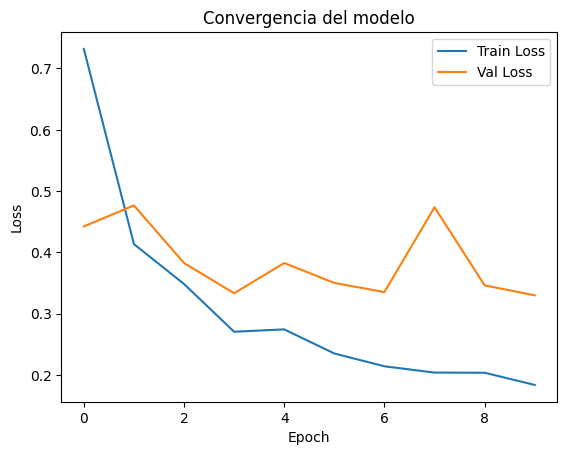

In [34]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Convergencia del modelo")
plt.legend()

plt.show()

# Matriz de confusión

La matriz de confusión muestra en general los mismos problemas que el modelo anterior. Pero con ciertos matices:
- La mayoria de las categorias tiene un descenso en el recall de entre 1 y 2 puntos porcentuales
- Pero lo verdaderamente interesante ocurre con la categoria **pasture** que tiene una fuerte caída hasta el **81%**

Esto nos da a entender que este modelo no es bueno clasificando plantaciones tanto anuales como permanentes.

- En algunas pruebas la categoria River bajó también su recall. Esto es un poco inesperado, que utilizando la misma base y tratando de utilizar un seed, los resultados varíen tanto en algunos casos (hasta 74% ha bajado en algunos casos)

- También para algunos experimentos la clase herbaceous vegetation ha bajado su recall fuertemente (en algunos casos al 65%) pero al igual que con la categoria river en otros experimentos llega al 85 y 90%

- **Esta variavilidad en el recall de algunas clases para algunos experimentos, no se observa en la ResNET.** Siendo está mucho más estable y consistente con sus resultados.

<Figure size 1200x800 with 0 Axes>

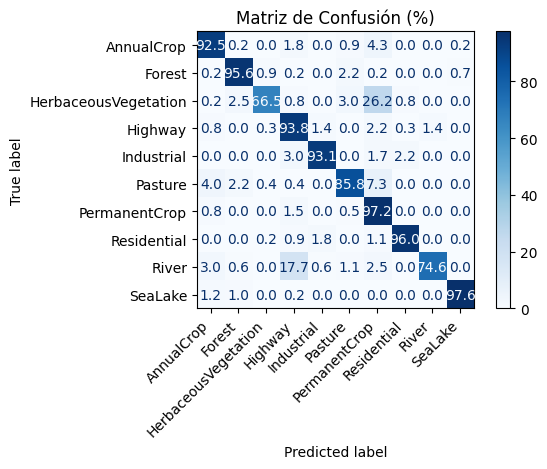

In [ ]:
y_true_vgg = []
y_pred_vgg = []

model.eval()

with torch.no_grad():
    for X, y in val_loader:
        X = X.to(device)

        outputs = model(X)
        _, preds = torch.max(outputs, 1)

        y_true_vgg.extend(y.numpy())
        y_pred_vgg.extend(preds.cpu().numpy())

# matriz de confusión normalizada
cm = confusion_matrix(y_true_vgg, y_pred_vgg, normalize='true')

# convertir a porcentaje
cm_percent = cm * 100

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_percent,
    display_labels=full_dataset.classes
)

plt.figure(figsize=(12, 8))

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    values_format=".1f"
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.title("Matriz de Confusión (%)")
plt.tight_layout()
plt.show()




# Métricas de evaluación

Es interesante revisar los casos de Permanentcrop, annualcrop y River, los cuales tienen un recall bajo. Pero su precisión es alta. Esto se puede interpretar como el modelo al momento de elegir estas categorias, lo hace con especial seguridad (y de forma correcta) pero está dejando pasar imagenes reales que no logra detectar. Esto lo podemos caracterizar como una falta de sensibilidad para estas caracteristicas.

In [ ]:
print(classification_report(
    y_true_vgg,
    y_pred_vgg,
    target_names=full_dataset.classes if hasattr(full_dataset, 'dataset') else full_dataset.classes
))

                      precision    recall  f1-score   support

          AnnualCrop       0.92      0.93      0.92       440
              Forest       0.95      0.96      0.95       457
HerbaceousVegetation       0.98      0.66      0.79       474
             Highway       0.78      0.94      0.85       370
          Industrial       0.96      0.93      0.94       363
             Pasture       0.87      0.86      0.87       274
       PermanentCrop       0.66      0.97      0.79       390
         Residential       0.97      0.96      0.97       453
               River       0.98      0.75      0.85       362
             SeaLake       0.99      0.98      0.98       417

            accuracy                           0.89      4000
           macro avg       0.91      0.89      0.89      4000
        weighted avg       0.91      0.89      0.89      4000



Evaluamos las imagenes propias de Google Earth

Zona residencial


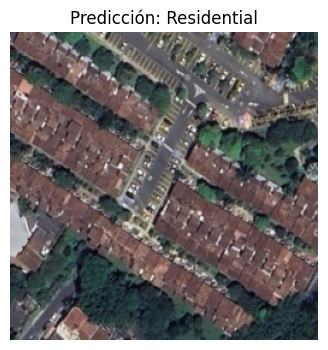

imagenes/unidad.jpg → Residential
Rio Putumayo


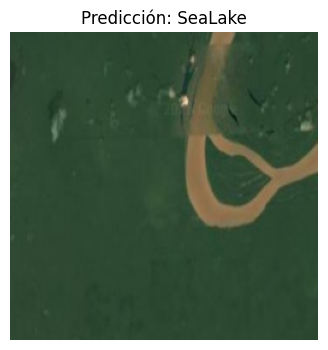

imagenes/rio putumayo.jpg → SeaLake
Guatapé


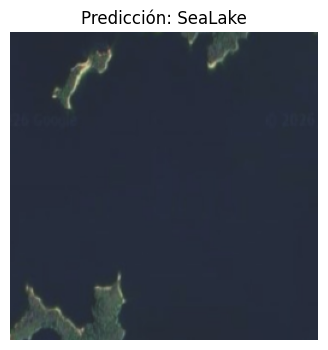

imagenes/guatape.jpg → SeaLake
Autopista norte


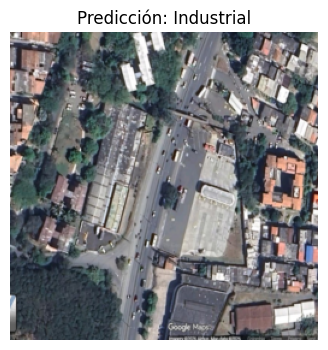

imagenes/autopista norte.jpg → Industrial
Azucar manuelita


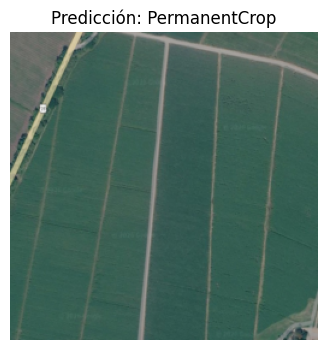

imagenes/azucar manuelita.jpg → PermanentCrop
Plaza minorista


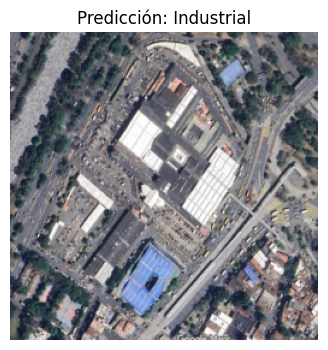

imagenes/plaza minorista.jpg → Industrial


In [ ]:
def predecir_imagen(path):
    img = Image.open(path).convert("RGB")
    img_display = transforms.Resize((256, 256))(img) # Resize for display
    img = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(img)
        _, pred = torch.max(outputs, 1)

    clase = full_dataset.classes[pred.item()]

    plt.figure(figsize=(4, 4))
    plt.imshow(img_display)
    plt.title(f"Predicción: {clase}")
    plt.axis('off')
    plt.show()

    print(path, "→", clase)

print("Zona residencial")
predecir_imagen(os.path.join(img_dir, "unidad.jpg"))
print("Rio Putumayo")
predecir_imagen(os.path.join(img_dir, "rio putumayo.jpg"))
print("Guatapé")
predecir_imagen(os.path.join(img_dir, "guatape.jpg"))
print("Autopista norte")
predecir_imagen(os.path.join(img_dir, "autopista norte.jpg"))
print("Azucar manuelita")
predecir_imagen(os.path.join(img_dir, "azucar manuelita.jpg"))
print("Plaza minorista")
predecir_imagen(os.path.join(img_dir, "plaza minorista.jpg"))

- La zona residencial es clasificada correctamente.

- El rio putumayo lo confunde con un lago, erroneo a diferencia del anterior modelo que lo confundía con bosque. Ambos modelos presentan dificultades para clasificar los rios.

- Guatapé es clasificado correctamente.

- La autopista norte la clasifica segun zona industrial, lo cuál no está mal. De igual forma que el modelo anterior.

- El ingenio de azucar lo clasifica como cultivo anual, a diferencia del anterior modelo que lo clasifica como cultivo permanente. Esto debe revisarse más a fondo, sobre cuáles son las caracteristicas de las imgenes de entrenamiento de Eurosat para estas dos categorias.

- La plaza minorista lo clasifica correctamente.

# Comparación de resultados

In [ ]:

results = []

def evaluar_modelo(nombre, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    results.append({
        "Modelo": nombre,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

evaluar_modelo("ResNet18", y_true_resnet, y_pred_resnet)
evaluar_modelo("VGG16", y_true_vgg, y_pred_vgg)

df_results = pd.DataFrame(results)
print(df_results)


     Modelo  Accuracy  Precision   Recall  F1-score
0  ResNet18   0.94575   0.946336  0.94575  0.945355
1     VGG16   0.89250   0.910592  0.89250  0.892972


# Conclusiones generales

- Inicialmente se realizaron pruebas con 1.000 y 2.000 imagenes, esto previniendo un entrenamiento extremadamente largo. Pero al optimizar el entrenamiento con la GPU tanto local, como  de Colab se observó que se podía aumentar la cantidad de la base de datos. Inicialmente con 1.000 y 2.000 imagenes se alcanzaba un accuracy de entre 85% y 90%. Pero al aumentar la cantidad a 10.000 ya subía entre 90% y 91%. Finalmente se trabajó con 20.000 imagenes alcanzando un accuracy de 94% aprox. Esto demuestra la no linealidad entre la cantidad de material de entrenamiento y el accuracy.

- Aunque también se observó que en los intentos de menor cantidad de imagenes, los modelos tendía a confundir la zona residencial de Envigado con una zona industrial.

- Para ninguna confguración los modelos lograron identificar el rio putumayo como rio, ni la autopista norte como autopista.

- Ambos modelos presentan debilidades y fortalezas en las mismas categorias, sugiriendo que la dificultad para clasificar estas no es inherente a la arquitectura del modelo. Destacan especificamente **pasture** y **river** con recalls de 90% o menos. Llegando a 81% en uno de los casos.

- Si bien se esperaba que la red VGG tardará más en entrenarse, la diferencia no fue tan abismal. Y para cantidades de 10.000 o menos imagenes, el modelo con VGG convergía más rápido que el ResNET. Esto podría ser explicable analizando que para menor cantidad de imagenes los calculos internos de saltos entre capas de ResNET tuvieran más peso computacional que los calculos secuenciales de VGG.

- El uso de GPU para el entrenamiento redujo entre 2 y 3 veces los calculos con CPU, demostrando la importancia de sacar provecho de las herramientas de hardware. Y algo interesante es que al utilizar GPU aun asi se esté utilizando una semilla al momento de partir los grupos de entrenamiento para el modelo, existen pequeñas variaciones en el accuracy y otras métricas. Esto es debido a la paralelilzación que hace la GPU para los calculos, los cuales no todos pueden ser estandarizados.
También, se observó que los tiempos de cálculo con GPU de colab variaban (posiblemente debido a la asignación de recursos y demanda que tenga en el momento el entorno) mientras que los calculos con GPU en local eran mucho más previsibles.

- El modelo que usa VGG genera una variabilidad alta en los resultados de accuracy y recall, a diferencia del modelo que usa ResNET que es mucho más consistente. Esto es importante de mencionar, ya que evidencia que la ResNET se adapta mejor a los cambios relacionados a las muestras de entrenamiento, siendo menos sensible.

- El segundo modelo a partir de VGG parece indicar un leve overfitting al final de su entrenamiento. Para este caso es recomendable continuar el analisis del modelo aumentando el numero de epocas y variando la información de entrenamiento, para comprobar si se trata de sobreajuste o una leve inestabilidad al momento de entrenar.